# Homework 3: Python Fundamentals

This notebook completes the Stage 3 assignment using NumPy and pandas. It demonstrates elementwise operations, compares loop and vectorized execution, explores the provided dataset, calculates summary statistics, aggregates by category, and saves the results.

In [1]:
from pathlib import Path
import sys
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Support running from either homework3/ or homework3/notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import get_summary_stats

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'starter_data.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## 1. NumPy operations

NumPy applies arithmetic to every array element without requiring an explicit Python loop.

In [2]:
numbers = np.arange(1, 11)
squared = numbers**2
scaled = numbers * 3 + 2

print('Original:', numbers)
print('Squared: ', squared)
print('3x + 2:  ', scaled)

Original: [ 1  2  3  4  5  6  7  8  9 10]
Squared:  [  1   4   9  16  25  36  49  64  81 100]
3x + 2:   [ 5  8 11 14 17 20 23 26 29 32]


In [3]:
# Compare equivalent loop-based and vectorized calculations.
large_array = np.arange(100_000)
loop_result = np.array([value**2 for value in large_array])
vectorized_result = large_array**2
assert np.array_equal(loop_result, vectorized_result)

loop_time = timeit.timeit(lambda: [value**2 for value in large_array], number=10)
vectorized_time = timeit.timeit(lambda: large_array**2, number=10)

print(f'Loop time (10 runs):       {loop_time:.4f} seconds')
print(f'Vectorized time (10 runs): {vectorized_time:.4f} seconds')
print(f'Vectorization speedup:      {loop_time / vectorized_time:.1f}x')

Loop time (10 runs):       0.0442 seconds
Vectorized time (10 runs): 0.0004 seconds
Vectorization speedup:      108.9x


The assertion confirms that both approaches produce identical values. The timing comparison shows that NumPy vectorization is faster because its elementwise work runs in optimized compiled code rather than a Python-level loop.

## 2. Dataset loading and inspection

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   category  10 non-null     object        
 1   value     10 non-null     int64         
 2   date      10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 372.0+ bytes


The dataset has 10 complete rows, one categorical column (`category`), one numeric column (`value`), and one parsed date column (`date`).

## 3. Summary statistics and grouped aggregation

In [6]:
# Use the imported reusable function to describe numeric columns.
summary = get_summary_stats(df)
summary

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [7]:
# Compare the value distribution for each category.
category_summary = (
    df.groupby('category', as_index=False)
      .agg(count=('value', 'count'), mean=('value', 'mean'),
           minimum=('value', 'min'), maximum=('value', 'max'))
)
category_summary

,category,count,mean,minimum,maximum
0,A,4,11.500000,10,13
1,B,3,15.666667,14,18
2,C,3,27.666667,25,30


Category C has the highest average value (about 27.7), while category A has the lowest (11.5). Category A appears four times; categories B and C each appear three times.

## 4. Save outputs

In [8]:
summary_path = OUTPUT_DIR / 'summary.csv'
category_summary_path = OUTPUT_DIR / 'category_summary.csv'
summary.to_csv(summary_path)
category_summary.to_csv(category_summary_path, index=False)

print(f'Saved numeric summary to {summary_path}')
print(f'Saved category summary to {category_summary_path}')

Saved numeric summary to /Users/marklanglois/Desktop/coding projects/NYU/bootcamp_mark_langlois/homework/homework3/data/processed/summary.csv
Saved category summary to /Users/marklanglois/Desktop/coding projects/NYU/bootcamp_mark_langlois/homework/homework3/data/processed/category_summary.csv


### Bonus: basic plot

hw03_python_fundamentals.ipynb:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  },
Saved plot to /Users/marklanglois/Desktop/coding projects/NYU/bootcamp_mark_langlois/homework/homework3/data/processed/average_value_by_category.png


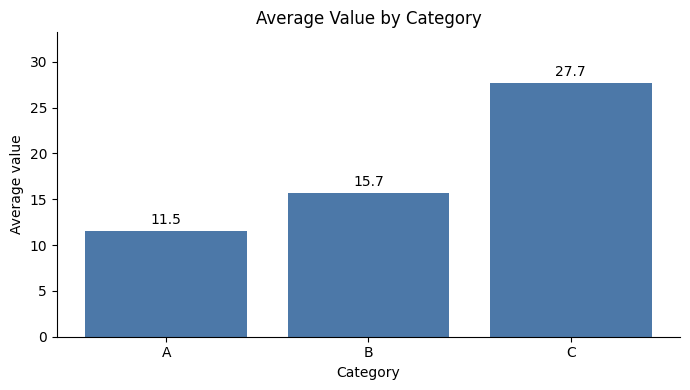

In [9]:
plot_path = OUTPUT_DIR / 'average_value_by_category.png'

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(category_summary['category'], category_summary['mean'], color='#4C78A8')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set(title='Average Value by Category', xlabel='Category', ylabel='Average value')
ax.set_ylim(0, category_summary['mean'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved plot to {plot_path}')

## Conclusion

The numeric values range from 10 to 30, with an overall mean of 17.6. Grouping reveals a clear difference among categories: C has the largest average, followed by B and then A. The analysis is reproducible because the summary logic lives in `src/utils.py` and all generated artifacts are saved under `data/processed/`.